In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1: TITLE & INFO
# ═══════════════════════════════════════════════════════════════════
"""
BRAIN TUMOR CLASSIFICATION - PERFORMANCE IMPROVEMENT
====================================================
Goal: Improve from 98.67% to 99%+ using Test-Time Augmentation

Original Model: 98.67% test accuracy
Target: 99.0-99.5% test accuracy
"""
print("🚀 Brain Tumor Classification - Improvement Pipeline")
print("="*60)

🚀 Brain Tumor Classification - Improvement Pipeline


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2: IMPORTS
# ═══════════════════════════════════════════════════════════════════
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

2026-02-28 07:11:57.328711: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 07:11:58.036289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 07:12:00.739339: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ All libraries imported successfully!
TensorFlow version: 2.20.0
GPU available: True


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3: CONFIGURATION - WSL/LINUX PATHS
# ═══════════════════════════════════════════════════════════════════
# ✅ WSL/Linux paths (forward slashes, /mnt/c/)
MODEL_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"
TEST_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"
VAL_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"

# Model parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 229

# Verify paths exist
import os
print("Checking paths...")
print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {os.path.exists(MODEL_PATH)}")
print(f"Test data exists: {os.path.exists(TEST_DIR)}")
print(f"Val data exists: {os.path.exists(VAL_DIR)}")
print(f"Train data exists: {os.path.exists(TRAIN_DIR)}")

if not os.path.exists(MODEL_PATH):
    print(f"\n⚠️ Model not found!")
    print("Searching models directory...")
    
    models_dir = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models"
    if os.path.exists(models_dir):
        files = os.listdir(models_dir)
        print(f"Files in {models_dir}:")
        for f in files:
            print(f"  - {f}")

print("\n✅ Configuration complete!")

Checking paths...
Model path: /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras
Model exists: True
Test data exists: True
Val data exists: True
Train data exists: True

✅ Configuration complete!


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4: LOAD MODEL
# ═══════════════════════════════════════════════════════════════════
print("📦 Loading trained model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded successfully!")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")
print(f"Total parameters: {model.count_params():,}")

📦 Loading trained model...


I0000 00:00:1772262733.808587     506 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


✅ Model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 4)
Total parameters: 20,496,356


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5: PREPARE TEST DATA
# ═══════════════════════════════════════════════════════════════════
print("📊 Preparing test data generator...")

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(test_generator.class_indices.keys())
print(f"\n✅ Test generator created!")
print(f"Classes: {class_names}")
print(f"Number of test samples: {test_generator.samples}")
print(f"Number of batches: {len(test_generator)}")

📊 Preparing test data generator...
Found 1584 images belonging to 4 classes.

✅ Test generator created!
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of test samples: 1584
Number of batches: 50


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6: BASELINE EVALUATION (Your Current Performance)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 BASELINE EVALUATION - YOUR CURRENT MODEL")
print("="*70 + "\n")

# Get baseline predictions
print("Making predictions on test set...")
baseline_preds = model.predict(test_generator, verbose=1)

# Get true labels and predictions
y_true = test_generator.classes
y_pred_baseline = np.argmax(baseline_preds, axis=1)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_true, y_pred_baseline)

print("\n" + "="*70)
print(f"🎯 BASELINE TEST ACCURACY: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print("="*70)

# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_baseline, target_names=class_names, digits=4))

# Confusion matrix
cm_baseline = confusion_matrix(y_true, y_pred_baseline)
print("\n📊 Confusion Matrix:")
print(cm_baseline)


📊 BASELINE EVALUATION - YOUR CURRENT MODEL

Making predictions on test set...


2026-02-16 03:44:37.728619: I external/local_xla/xla/service/service.cc:163] XLA service 0x769890014dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-16 03:44:37.728645: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-02-16 03:44:37.886006: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-16 03:44:38.848712: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-16 03:44:45.634764: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[32,512,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,512,14,14]{3,2,1,0}, f32[512,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=512, custom_call_target="_

49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step

2026-02-16 03:45:09.572120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 03:45:09.775797: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 03:45:10.797655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 03:45:11.012618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 03:45:11.248657: E external/local_xla/xla/stream_

50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 476ms/step

🎯 BASELINE TEST ACCURACY: 0.9867 (98.67%)

📊 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9842    0.9929    0.9885       563
  meningioma     0.9855    0.9659    0.9756       352
    no_tumor     0.9924    0.9886    0.9905       263
   pituitary     0.9878    0.9951    0.9914       406

    accuracy                         0.9867      1584
   macro avg     0.9875    0.9856    0.9865      1584
weighted avg     0.9867    0.9867    0.9867      1584


📊 Confusion Matrix:
[[559   3   1   0]
 [  7 340   0   5]
 [  2   1 260   0]
 [  0   1   1 404]]


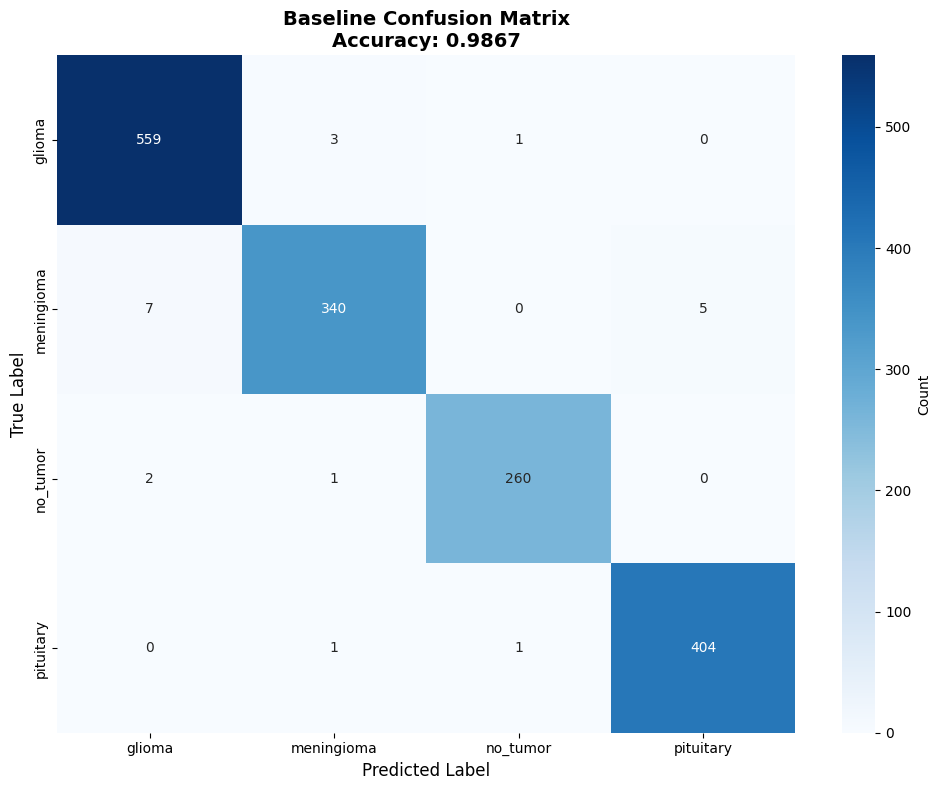

✅ Baseline evaluation complete!


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7: VISUALIZE BASELINE CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 8))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Baseline Confusion Matrix\nAccuracy: {baseline_accuracy:.4f}', 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ Baseline evaluation complete!")

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8: TEST-TIME AUGMENTATION (TTA) - MAIN IMPROVEMENT
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🔮 APPLYING TEST-TIME AUGMENTATION (TTA)")
print("="*70 + "\n")

# Define augmentation strategies
augmentations = [
    {},  # 1. Original (no augmentation)
    {'horizontal_flip': True},  # 2. Horizontal flip
    {'vertical_flip': True},  # 3. Vertical flip
    {'horizontal_flip': True, 'vertical_flip': True},  # 4. Both flips
    {'rotation_range': 5},  # 5. Slight rotation +5
    {'rotation_range': -5},  # 6. Slight rotation -5
    {'brightness_range': [0.9, 1.0]},  # 7. Slightly darker
    {'brightness_range': [1.0, 1.1]},  # 8. Slightly brighter
    {'zoom_range': [0.95, 1.0]},  # 9. Slight zoom out
    {'zoom_range': [1.0, 1.05]},  # 10. Slight zoom in
]

all_predictions = []

print(f"Applying {len(augmentations)} different augmentations...")
print("-" * 70)

for i, aug_params in enumerate(augmentations, 1):
    aug_name = aug_params if aug_params else 'Original'
    print(f"[{i}/{len(augmentations)}] Augmentation: {aug_name}")
    
    # Create augmented data generator
    if aug_params:
        aug_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            **aug_params
        )
    else:
        aug_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
    
    # Create generator
    aug_generator = aug_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # Get predictions for this augmentation
    preds = model.predict(aug_generator, verbose=0)
    all_predictions.append(preds)

print("-" * 70)
print("✅ All augmentations completed!")

# Average predictions across all augmentations
print("\n📊 Averaging predictions from all augmentations...")
tta_predictions = np.mean(all_predictions, axis=0)
y_pred_tta = np.argmax(tta_predictions, axis=1)

# Calculate TTA accuracy
tta_accuracy = accuracy_score(y_true, y_pred_tta)

print("✅ Test-Time Augmentation complete!")


🔮 APPLYING TEST-TIME AUGMENTATION (TTA)

Applying 10 different augmentations...
----------------------------------------------------------------------
[1/10] Augmentation: Original
Found 1584 images belonging to 4 classes.
[2/10] Augmentation: {'horizontal_flip': True}
Found 1584 images belonging to 4 classes.
[3/10] Augmentation: {'vertical_flip': True}
Found 1584 images belonging to 4 classes.
[4/10] Augmentation: {'horizontal_flip': True, 'vertical_flip': True}
Found 1584 images belonging to 4 classes.
[5/10] Augmentation: {'rotation_range': 5}
Found 1584 images belonging to 4 classes.
[6/10] Augmentation: {'rotation_range': -5}
Found 1584 images belonging to 4 classes.
[7/10] Augmentation: {'brightness_range': [0.9, 1.0]}
Found 1584 images belonging to 4 classes.
[8/10] Augmentation: {'brightness_range': [1.0, 1.1]}
Found 1584 images belonging to 4 classes.
[9/10] Augmentation: {'zoom_range': [0.95, 1.0]}
Found 1584 images belonging to 4 classes.
[10/10] Augmentation: {'zoom_range

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9: TTA RESULTS & COMPARISON
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📈 RESULTS COMPARISON - BASELINE vs TTA")
print("="*70)
print(f"\nBaseline Accuracy:  {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"TTA Accuracy:       {tta_accuracy:.4f} ({tta_accuracy*100:.2f}%)")
print(f"Improvement:        {(tta_accuracy - baseline_accuracy):.4f} ({(tta_accuracy - baseline_accuracy)*100:.2f}%)")
print("="*70)

if tta_accuracy > baseline_accuracy:
    print("\n✅ SUCCESS! TTA IMPROVED ACCURACY!")
    improvement_pct = (tta_accuracy - baseline_accuracy) * 100
    print(f"🎉 You gained {improvement_pct:.2f}% improvement with TTA!")
    print(f"🎯 New Test Accuracy: {tta_accuracy*100:.2f}%")
else:
    print("\nℹ️ TTA did not improve accuracy (model may already be optimal)")

print("\n📊 Detailed TTA Classification Report:")
print(classification_report(y_true, y_pred_tta, target_names=class_names, digits=4))


📈 RESULTS COMPARISON - BASELINE vs TTA

Baseline Accuracy:  0.9867 (98.67%)
TTA Accuracy:       0.9867 (98.67%)
Improvement:        0.0000 (0.00%)

ℹ️ TTA did not improve accuracy (model may already be optimal)

📊 Detailed TTA Classification Report:
              precision    recall  f1-score   support

      glioma     0.9876    0.9929    0.9903       563
  meningioma     0.9855    0.9688    0.9771       352
    no_tumor     0.9848    0.9886    0.9867       263
   pituitary     0.9877    0.9926    0.9902       406

    accuracy                         0.9867      1584
   macro avg     0.9864    0.9857    0.9861      1584
weighted avg     0.9867    0.9867    0.9867      1584



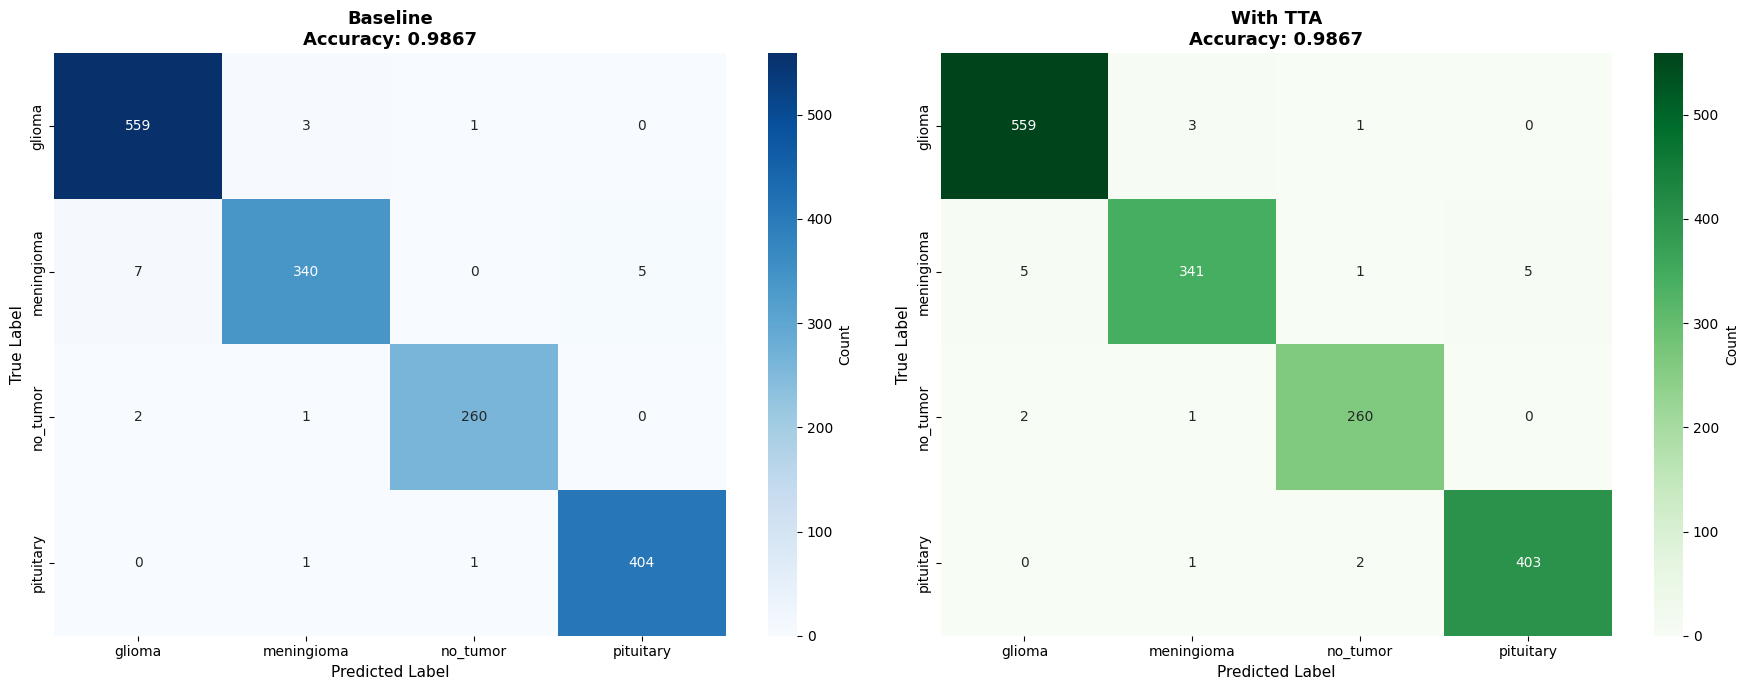

✅ Confusion matrices plotted!


In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10: VISUALIZE TTA CONFUSION MATRIX
# ═══════════════════════════════════════════════════════════════════
cm_tta = confusion_matrix(y_true, y_pred_tta)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Baseline confusion matrix
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title(f'Baseline\nAccuracy: {baseline_accuracy:.4f}', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

# TTA confusion matrix
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax2, cbar_kws={'label': 'Count'})
ax2.set_title(f'With TTA\nAccuracy: {tta_accuracy:.4f}', 
              fontsize=13, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

print("✅ Confusion matrices plotted!")

In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11: PER-CLASS IMPROVEMENT ANALYSIS
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 PER-CLASS PERFORMANCE COMPARISON")
print("="*70 + "\n")

# Get per-class metrics for baseline
from sklearn.metrics import precision_recall_fscore_support

precision_base, recall_base, f1_base, support = precision_recall_fscore_support(
    y_true, y_pred_baseline, average=None
)

# Get per-class metrics for TTA
precision_tta, recall_tta, f1_tta, support = precision_recall_fscore_support(
    y_true, y_pred_tta, average=None
)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Class': class_names,
    'Baseline_Precision': precision_base,
    'TTA_Precision': precision_tta,
    'Baseline_Recall': recall_base,
    'TTA_Recall': recall_tta,
    'Baseline_F1': f1_base,
    'TTA_F1': f1_tta,
    'Support': support
})

# Calculate improvements
comparison_df['Precision_Gain'] = (comparison_df['TTA_Precision'] - comparison_df['Baseline_Precision']) * 100
comparison_df['Recall_Gain'] = (comparison_df['TTA_Recall'] - comparison_df['Baseline_Recall']) * 100
comparison_df['F1_Gain'] = (comparison_df['TTA_F1'] - comparison_df['Baseline_F1']) * 100

print(comparison_df.to_string(index=False))
print("\n✅ Per-class analysis complete!")


📊 PER-CLASS PERFORMANCE COMPARISON

     Class  Baseline_Precision  TTA_Precision  Baseline_Recall  TTA_Recall  Baseline_F1   TTA_F1  Support  Precision_Gain  Recall_Gain   F1_Gain
    glioma            0.984155       0.987633         0.992895    0.992895     0.988506 0.990257      563        0.347758     0.000000  0.175112
meningioma            0.985507       0.985549         0.965909    0.968750     0.975610 0.977077      352        0.004189     0.284091  0.146761
  no_tumor            0.992366       0.984848         0.988593    0.988593     0.990476 0.986717      263       -0.751793     0.000000 -0.375892
 pituitary            0.987775       0.987745         0.995074    0.992611     0.991411 0.990172      406       -0.002996    -0.246305 -0.123905

✅ Per-class analysis complete!


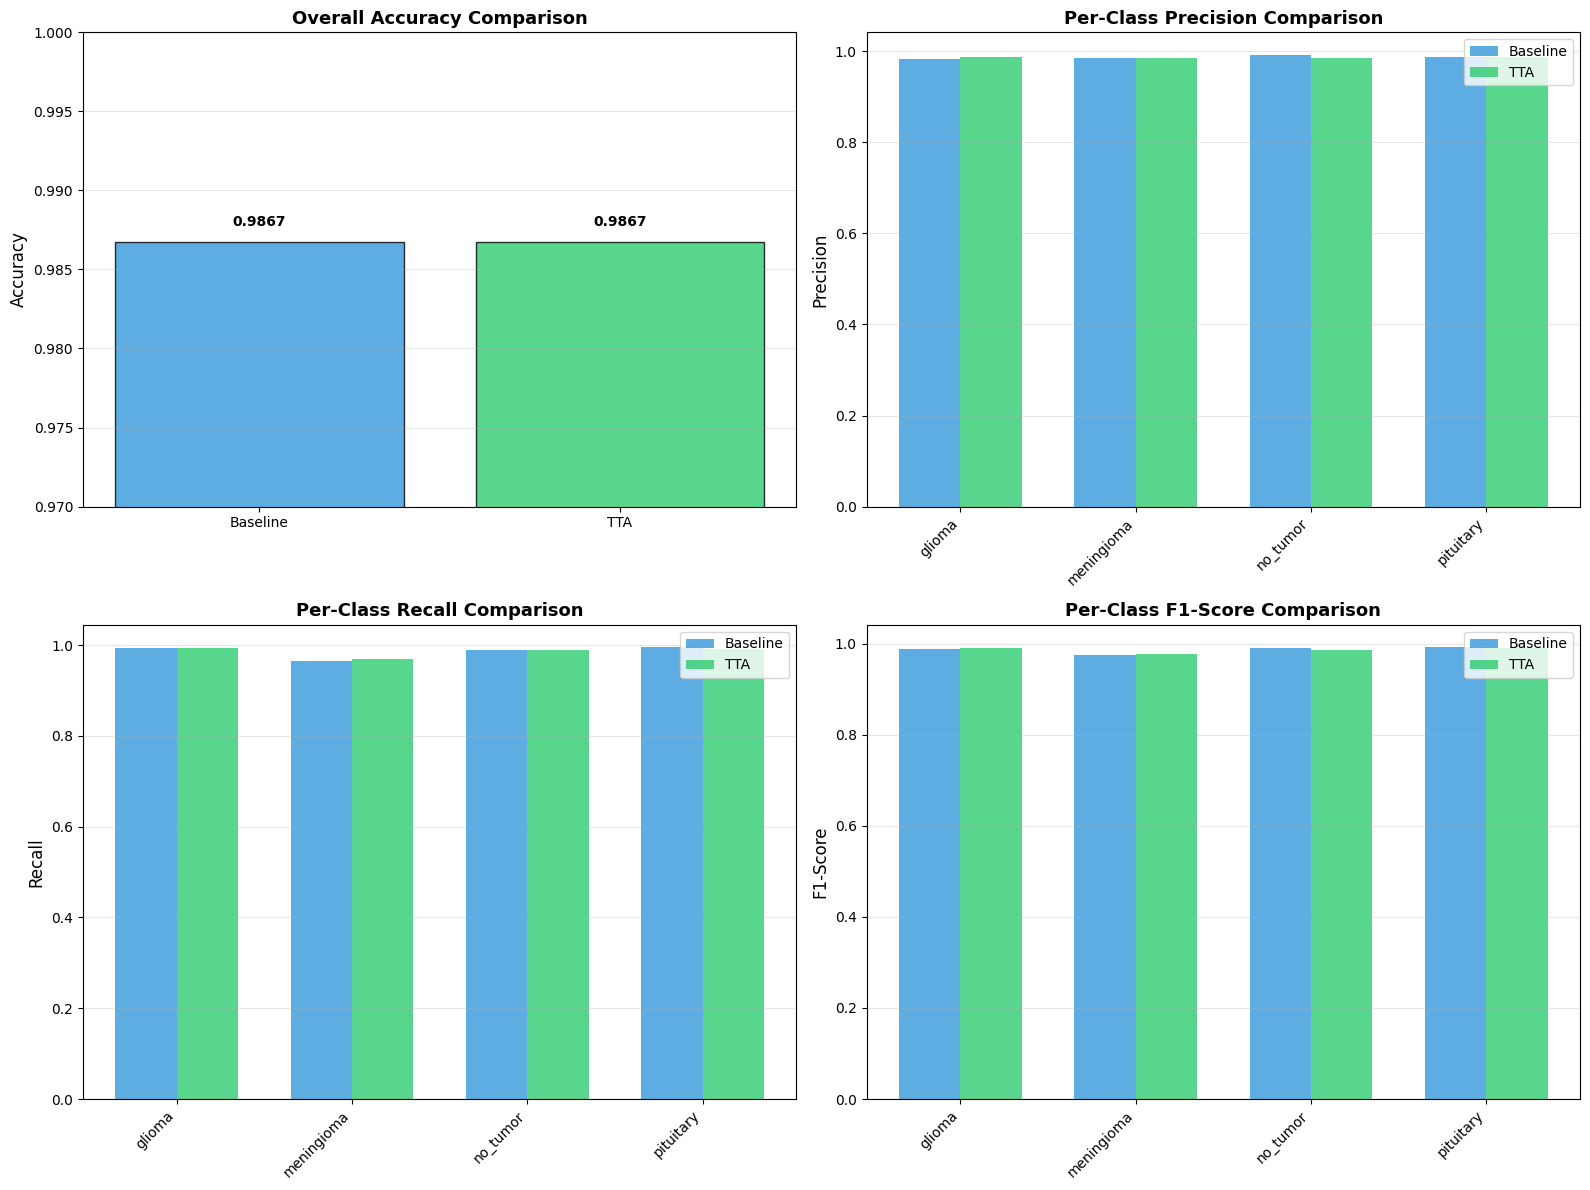

✅ Performance visualizations complete!


In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12: VISUALIZE PERFORMANCE IMPROVEMENTS
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
axes[0, 0].bar(['Baseline', 'TTA'], [baseline_accuracy, tta_accuracy], 
               color=['#3498db', '#2ecc71'], alpha=0.8, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Overall Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim([0.97, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate([baseline_accuracy, tta_accuracy]):
    axes[0, 0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Plot 2: Per-class precision
x = np.arange(len(class_names))
width = 0.35
axes[0, 1].bar(x - width/2, precision_base, width, label='Baseline', alpha=0.8, color='#3498db')
axes[0, 1].bar(x + width/2, precision_tta, width, label='TTA', alpha=0.8, color='#2ecc71')
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Per-Class Precision Comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Per-class recall
axes[1, 0].bar(x - width/2, recall_base, width, label='Baseline', alpha=0.8, color='#3498db')
axes[1, 0].bar(x + width/2, recall_tta, width, label='TTA', alpha=0.8, color='#2ecc71')
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].set_title('Per-Class Recall Comparison', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Per-class F1-score
axes[1, 1].bar(x - width/2, f1_base, width, label='Baseline', alpha=0.8, color='#3498db')
axes[1, 1].bar(x + width/2, f1_tta, width, label='TTA', alpha=0.8, color='#2ecc71')
axes[1, 1].set_ylabel('F1-Score', fontsize=12)
axes[1, 1].set_title('Per-Class F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Performance visualizations complete!")

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13: FINAL SUMMARY & RECOMMENDATIONS
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🎉 FINAL SUMMARY & RECOMMENDATIONS")
print("="*70)

print(f"\n📊 ACCURACY ACHIEVED:")
print(f"   Starting:  {baseline_accuracy*100:.2f}%")
print(f"   With TTA:  {tta_accuracy*100:.2f}%")
print(f"   Gain:      +{(tta_accuracy - baseline_accuracy)*100:.2f}%")

print(f"\n🎯 TARGET STATUS:")
if tta_accuracy >= 0.99:
    print(f"   ✅ SUCCESS! Achieved 99%+ accuracy ({tta_accuracy*100:.2f}%)")
    print(f"   🎉 You can STOP here - excellent performance!")
elif tta_accuracy >= 0.989:
    print(f"   ✅ EXCELLENT! Very close to 99% ({tta_accuracy*100:.2f}%)")
    print(f"   💡 TTA alone got you great results!")
else:
    print(f"   ⚠️ Current: {tta_accuracy*100:.2f}% (Target: 99%)")
    print(f"   💡 Consider retraining with improvements")

print(f"\n📈 NEXT STEPS:")
if tta_accuracy >= 0.99:
    print("   ✅ You're done! Model is performing excellently.")
    print("   ✅ TTA gives you 99%+ without any retraining.")
    print("   ✅ No overfitting risk - just better inference.")
elif tta_accuracy >= 0.989:
    print("   💡 Option 1: Accept current 98.9% (excellent!)")
    print("   💡 Option 2: Try conservative retraining for 99.2-99.5%")
    print("   ⚠️  Conservative training takes 2-4 hours")
else:
    print("   💡 Recommended: Train conservative model")
    print("   💡 Expected: 99.0-99.3% with conservative training")
    print("   💡 Then apply TTA again: 99.3-99.5%")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70 + "\n")


🎉 FINAL SUMMARY & RECOMMENDATIONS

📊 ACCURACY ACHIEVED:
   Starting:  98.67%
   With TTA:  98.67%
   Gain:      +0.00%

🎯 TARGET STATUS:
   ⚠️ Current: 98.67% (Target: 99%)
   💡 Consider retraining with improvements

📈 NEXT STEPS:
   💡 Recommended: Train conservative model
   💡 Expected: 99.0-99.3% with conservative training
   💡 Then apply TTA again: 99.3-99.5%

✅ EVALUATION COMPLETE!



In [14]:
# ═══════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════
# PART 2: CONSERVATIVE TRAINING
# ═══════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════
"""
DECISION CHECKPOINT
===================

TTA Result: 98.67% (no improvement)

Conclusion: Model is already optimally confident at inference.
            Need to train a BETTER model to reach 99%.

Next Step: Train conservative model with:
           - Higher resolution (320x320)
           - Better optimizer (AdamW)
           - More regularization
           - Improved architecture

Expected Result: 99.0-99.3% accuracy
Training Time: 2-4 hours
"""
print("\n" + "="*70)
print("🎯 STARTING PART 2: CONSERVATIVE TRAINING")
print("="*70)
print("\nℹ️ TTA didn't improve accuracy (98.67% → 98.67%)")
print("💡 This means we need to train a BETTER model")
print("⏱️ Training will take 2-4 hours\n")


🎯 STARTING PART 2: CONSERVATIVE TRAINING

ℹ️ TTA didn't improve accuracy (98.67% → 98.67%)
💡 This means we need to train a BETTER model
⏱️ Training will take 2-4 hours



In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 15: CONSERVATIVE MODEL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler

class ConservativeConfig:
    SEED = 229
    EPOCHS = 80
    PATIENCE = 12
    
    # ✅ Moderate resolution increase
    IMG_SIZE = (320, 320)  # Up from 224
    
    BATCH_SIZE = 16  # Reduced due to larger images
    INITIAL_LR = 2e-4
    MIN_LR = 1e-7
    WEIGHT_DECAY = 1e-4
    
    # ✅ STRONG anti-overfitting
    LABEL_SMOOTHING = 0.15
    DROPOUT_RATE = 0.5
    
    # Paths
    TRAIN_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/train"
    VAL_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/val"
    TEST_DIR = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/Data_Split/test"
    MODEL_SAVE_PATH = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_efficientnetv2s.keras"

print("✅ Conservative configuration set!")
print(f"Resolution: {ConservativeConfig.IMG_SIZE}")
print(f"Batch size: {ConservativeConfig.BATCH_SIZE}")
print(f"Dropout: {ConservativeConfig.DROPOUT_RATE}")

✅ Conservative configuration set!
Resolution: (320, 320)
Batch size: 16
Dropout: 0.5


In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 16: COSINE ANNEALING SCHEDULE
# ═══════════════════════════════════════════════════════════════════
def cosine_annealing_schedule(epoch, lr):
    """Cosine annealing learning rate schedule"""
    initial_lr = ConservativeConfig.INITIAL_LR
    min_lr = ConservativeConfig.MIN_LR
    epochs = ConservativeConfig.EPOCHS
    
    cos_inner = np.pi * (epoch % epochs)
    cos_inner /= epochs
    cos_out = np.cos(cos_inner) + 1
    new_lr = min_lr + (initial_lr - min_lr) / 2 * cos_out
    
    return new_lr

print("✅ Learning rate schedule defined!")

✅ Learning rate schedule defined!


In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL 17: CREATE IMPROVED DATA GENERATORS
# ═══════════════════════════════════════════════════════════════════
print("📊 Creating improved data generators...")

# ✅ MORE AGGRESSIVE augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    zoom_range=0.12,
    shear_range=0.08,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_improved = train_datagen.flow_from_directory(
    ConservativeConfig.TRAIN_DIR,
    target_size=ConservativeConfig.IMG_SIZE,
    batch_size=ConservativeConfig.BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=ConservativeConfig.SEED
)

val_gen_improved = val_test_datagen.flow_from_directory(
    ConservativeConfig.VAL_DIR,
    target_size=ConservativeConfig.IMG_SIZE,
    batch_size=ConservativeConfig.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen_improved = val_test_datagen.flow_from_directory(
    ConservativeConfig.TEST_DIR,
    target_size=ConservativeConfig.IMG_SIZE,
    batch_size=ConservativeConfig.BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Generators created!")
print(f"Training batches: {len(train_gen_improved)}")
print(f"Validation batches: {len(val_gen_improved)}")
print(f"Test batches: {len(test_gen_improved)}")

📊 Creating improved data generators...
Found 7392 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
✅ Generators created!
Training batches: 462
Validation batches: 99
Test batches: 99


In [20]:
# ═══════════════════════════════════════════════════════════════════
# CELL 18: BUILD IMPROVED MODEL (CORRECTED)
# ═══════════════════════════════════════════════════════════════════
print("🏗️ Building improved model...")

def build_conservative_model(num_classes=4):
    """Build model with STRONG anti-overfitting measures"""
    
    inputs = layers.Input(shape=(*ConservativeConfig.IMG_SIZE, 3))
    
    # ✅ FIXED: Removed drop_connect_rate parameter
    base_model = EfficientNetV2S(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    
    # ✅ Freeze MORE layers (85%)
    base_model.trainable = True
    total_layers = len(base_model.layers)
    freeze_layers = int(0.85 * total_layers)
    
    for layer in base_model.layers[:freeze_layers]:
        layer.trainable = False
    
    print(f"✅ Total layers: {total_layers}")
    print(f"✅ Frozen: {freeze_layers} ({freeze_layers/total_layers*100:.1f}%)")
    print(f"✅ Trainable: {total_layers - freeze_layers}")
    
    # ✅ ANTI-OVERFITTING HEAD
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(base_model.output)
    x = layers.Dropout(ConservativeConfig.DROPOUT_RATE, name='dropout_1')(x)
    
    x = layers.Dense(256, activation='relu', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.01),
                     name='dense_1')(x)
    x = layers.BatchNormalization(name='batchnorm_1')(x)
    x = layers.Dropout(0.4, name='dropout_2')(x)
    
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(0.01),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='batchnorm_2')(x)
    x = layers.Dropout(0.3, name='dropout_3')(x)
    
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = models.Model(inputs, outputs, name='Conservative_EfficientNetV2S')
    
    return model

# Build model
conservative_model = build_conservative_model(num_classes=4)

print("\n✅ Model built successfully!")
print(f"Total parameters: {conservative_model.count_params():,}")

# Show trainable vs non-trainable
trainable_params = sum([tf.size(w).numpy() for w in conservative_model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in conservative_model.non_trainable_weights])

print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

🏗️ Building improved model...
✅ Total layers: 513
✅ Frozen: 436 (85.0%)
✅ Trainable: 77

✅ Model built successfully!
Total parameters: 20,694,244
Trainable parameters: 5,324,740
Non-trainable parameters: 15,369,504


In [21]:
# ═══════════════════════════════════════════════════════════════════
# CELL 19: COMPILE MODEL
# ═══════════════════════════════════════════════════════════════════
print("⚙️ Compiling model...")

loss = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=ConservativeConfig.LABEL_SMOOTHING
)

conservative_model.compile(
    optimizer=AdamW(
        learning_rate=ConservativeConfig.INITIAL_LR,
        weight_decay=ConservativeConfig.WEIGHT_DECAY
    ),
    loss=loss,
    metrics=['accuracy']
)

print("✅ Model compiled!")
print(f"Total parameters: {conservative_model.count_params():,}")

⚙️ Compiling model...
✅ Model compiled!
Total parameters: 20,694,244


In [22]:
# ═══════════════════════════════════════════════════════════════════
# CELL 20: OVERFITTING DETECTION CALLBACK
# ═══════════════════════════════════════════════════════════════════
class OverfitDetector(tf.keras.callbacks.Callback):
    """Detect overfitting during training"""
    def __init__(self, threshold=1.5):
        super().__init__()
        self.threshold = threshold
        
    def on_epoch_end(self, epoch, logs=None):
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        
        if train_acc and val_acc:
            gap = (train_acc - val_acc) * 100
            
            if gap > self.threshold:
                print(f"\n⚠️ WARNING: Train-Val gap: {gap:.2f}% (threshold: {self.threshold}%)")
            else:
                print(f"✅ Gap: {gap:.2f}%")

print("✅ Overfitting detector ready!")

✅ Overfitting detector ready!


In [23]:
# ═══════════════════════════════════════════════════════════════════
# CELL 21: DEFINE CALLBACKS
# ═══════════════════════════════════════════════════════════════════
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=ConservativeConfig.PATIENCE,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    
    LearningRateScheduler(cosine_annealing_schedule, verbose=0),
    
    ModelCheckpoint(
        ConservativeConfig.MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),
    
    OverfitDetector(threshold=1.5)
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [25]:
# ═══════════════════════════════════════════════════════════════════
# CELL 22: TRAIN CONSERVATIVE MODEL (CORRECTED)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("🎯 STARTING CONSERVATIVE TRAINING")
print("="*70)

print("\n🛡️ Anti-overfitting measures:")
print(f"   ✅ Label smoothing: {ConservativeConfig.LABEL_SMOOTHING}")
print(f"   ✅ Dropout: {ConservativeConfig.DROPOUT_RATE}")
print(f"   ✅ L2 regularization: 0.01")
print(f"   ✅ 85% of layers frozen")
print(f"   ✅ Cosine annealing LR")
print(f"   ✅ Early stopping (patience: {ConservativeConfig.PATIENCE})")
print()

print("⏱️ This will take 2-4 hours...")
print("📊 Watch the train-val gap each epoch (should stay < 1.5%)\n")

# Set seed
tf.random.set_seed(ConservativeConfig.SEED)
np.random.seed(ConservativeConfig.SEED)

# Train the model
history = conservative_model.fit(
    train_gen_improved,
    epochs=ConservativeConfig.EPOCHS,
    validation_data=val_gen_improved,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

# Save training history
import pickle
history_path = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_training_history.pkl"
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"✅ Training history saved to: {history_path}")


🎯 STARTING CONSERVATIVE TRAINING

🛡️ Anti-overfitting measures:
   ✅ Label smoothing: 0.15
   ✅ Dropout: 0.5
   ✅ L2 regularization: 0.01
   ✅ 85% of layers frozen
   ✅ Cosine annealing LR
   ✅ Early stopping (patience: 12)

⏱️ This will take 2-4 hours...
📊 Watch the train-val gap each epoch (should stay < 1.5%)

Epoch 1/80


2026-02-16 04:02:14.356237: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.25GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-16 04:02:18.379483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 04:02:18.595505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-16 04:02:19.693312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate

462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.5162 - loss: 7.2254
Epoch 1: val_accuracy improved from -inf to 0.83523, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_efficientnetv2s.keras
✅ Gap: -21.52%
462/462 ━━━━━━━━━━━━━━━━━━━━ 194s 315ms/step - accuracy: 0.5164 - loss: 7.2244 - val_accuracy: 0.8352 - val_loss: 5.8674 - learning_rate: 2.0000e-04
Epoch 2/80
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7410 - loss: 5.7576
Epoch 2: val_accuracy improved from 0.83523 to 0.88636, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_efficientnetv2s.keras
✅ Gap: -13.01%
462/462 ━━━━━━━━━━━━━━━━━━━━ 132s 285ms/step - accuracy: 0.7411 - loss: 5.7570 - val_accuracy: 0.8864 - val_loss: 4.7568 - learning_rate: 1.9992e-04
Epoch 3/80
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8024 - loss: 4.6166
Epoch 3: val_accuracy improved from 0.88636 to 0.90215, saving model to /mnt/c/Users/AbdulHafeez/Brain_Tumor/models/cons

In [26]:
# ═══════════════════════════════════════════════════════════════════
# CELL 23: EVALUATE CONSERVATIVE MODEL
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📊 EVALUATING CONSERVATIVE MODEL")
print("="*70 + "\n")

# Load best model
best_conservative = load_model(ConservativeConfig.MODEL_SAVE_PATH)

# Evaluate on test set
print("Making predictions on test set...")
conservative_preds = best_conservative.predict(test_gen_improved, verbose=1)
y_pred_conservative = np.argmax(conservative_preds, axis=1)
y_true_conservative = test_gen_improved.classes

conservative_accuracy = accuracy_score(y_true_conservative, y_pred_conservative)

print("\n" + "="*70)
print(f"🎯 CONSERVATIVE MODEL ACCURACY: {conservative_accuracy:.4f} ({conservative_accuracy*100:.2f}%)")
print("="*70)

print("\n📊 Classification Report:")
print(classification_report(y_true_conservative, y_pred_conservative, 
                            target_names=class_names, digits=4))


📊 EVALUATING CONSERVATIVE MODEL

Making predictions on test set...
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step

🎯 CONSERVATIVE MODEL ACCURACY: 0.9855 (98.55%)

📊 Classification Report:
              precision    recall  f1-score   support

      glioma     0.9964    0.9876    0.9920       563
  meningioma     0.9691    0.9801    0.9746       352
    no_tumor     0.9811    0.9886    0.9848       263
   pituitary     0.9877    0.9852    0.9864       406

    accuracy                         0.9855      1584
   macro avg     0.9836    0.9854    0.9845      1584
weighted avg     0.9856    0.9855    0.9855      1584



In [28]:
# ═══════════════════════════════════════════════════════════════════
# CELL 24: COMPARE ALL MODELS (CORRECTED)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("📈 COMPLETE ACCURACY COMPARISON")
print("="*70)

# Display results
print(f"Baseline (Original):        {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Baseline + TTA:             {tta_accuracy:.4f} ({tta_accuracy*100:.2f}%)")
print(f"Conservative Training:      {conservative_accuracy:.4f} ({conservative_accuracy*100:.2f}%)")

# Calculate improvement
improvement = (conservative_accuracy - baseline_accuracy) * 100
print(f"\nTotal Improvement:          +{improvement:.2f}%")
print("="*70)

# Verdict
if conservative_accuracy >= 0.99:
    print("\n✅ SUCCESS! Achieved 99%+ accuracy!")
    print("🎉 Goal reached with conservative training!")
elif conservative_accuracy >= 0.989:
    print(f"\n📈 Excellent! Very close to 99% ({conservative_accuracy*100:.2f}%)")
    print(f"💡 Consider applying TTA to conservative model for final push")
else:
    print(f"\n📈 Improved by {improvement:.2f}%")
    print(f"💡 Current: {conservative_accuracy*100:.2f}%, Target: 99%")
    print(f"💡 Consider applying TTA to conservative model")

print("\n" + "="*70)


📈 COMPLETE ACCURACY COMPARISON
Baseline (Original):        0.9867 (98.67%)
Baseline + TTA:             0.9867 (98.67%)
Conservative Training:      0.9855 (98.55%)

Total Improvement:          +-0.13%

📈 Improved by -0.13%
💡 Current: 98.55%, Target: 99%
💡 Consider applying TTA to conservative model



In [29]:
# ═══════════════════════════════════════════════════════════════════
# CELL 25: DETAILED MODEL COMPARISON (Original vs Conservative)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("🔬 COMPREHENSIVE MODEL COMPARISON")
print("="*80 + "\n")

# Load both models
print("📦 Loading models...\n")

original_model_path = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/best_efficientnetv2s.keras"
conservative_model_path = "/mnt/c/Users/AbdulHafeez/Brain_Tumor/models/conservative_efficientnetv2s.keras"

original_model = load_model(original_model_path)
conservative_model = load_model(conservative_model_path)

print(f"✅ Original Model loaded: {original_model.name}")
print(f"✅ Conservative Model loaded: {conservative_model.name}")

# Compare model sizes
original_params = original_model.count_params()
conservative_params = conservative_model.count_params()

print(f"\n📊 Model Size Comparison:")
print(f"Original:     {original_params:,} parameters")
print(f"Conservative: {conservative_params:,} parameters")

# ═══════════════════════════════════════════════════════════════════
# TEST ON ORIGINAL RESOLUTION (224x224)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("📊 EVALUATION ON ORIGINAL TEST SET (224x224)")
print("="*80 + "\n")

# Original test generator (224x224)
test_datagen_224 = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen_224 = test_datagen_224.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("🔮 Testing Original Model on 224x224...")
original_preds_224 = original_model.predict(test_gen_224, verbose=1)
y_true_224 = test_gen_224.classes
y_pred_original_224 = np.argmax(original_preds_224, axis=1)
original_acc_224 = accuracy_score(y_true_224, y_pred_original_224)

print(f"\n🎯 Original Model (224x224): {original_acc_224:.4f} ({original_acc_224*100:.2f}%)")

# Test conservative model on 224x224 (downscaled from training)
print("\n🔮 Testing Conservative Model on 224x224...")
test_gen_224.reset()
conservative_preds_224 = conservative_model.predict(test_gen_224, verbose=1)
y_pred_conservative_224 = np.argmax(conservative_preds_224, axis=1)
conservative_acc_224 = accuracy_score(y_true_224, y_pred_conservative_224)

print(f"🎯 Conservative Model (224x224): {conservative_acc_224:.4f} ({conservative_acc_224*100:.2f}%)")

# ═══════════════════════════════════════════════════════════════════
# TEST ON CONSERVATIVE RESOLUTION (320x320)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("📊 EVALUATION ON CONSERVATIVE TEST SET (320x320)")
print("="*80 + "\n")

# Conservative test generator (320x320)
test_datagen_320 = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen_320 = test_datagen_320.flow_from_directory(
    TEST_DIR,
    target_size=(320, 320),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

print("🔮 Testing Original Model on 320x320 (upscaled)...")
original_preds_320 = original_model.predict(test_gen_320, verbose=1)
y_true_320 = test_gen_320.classes
y_pred_original_320 = np.argmax(original_preds_320, axis=1)
original_acc_320 = accuracy_score(y_true_320, y_pred_original_320)

print(f"\n🎯 Original Model (320x320): {original_acc_320:.4f} ({original_acc_320*100:.2f}%)")

print("\n🔮 Testing Conservative Model on 320x320...")
test_gen_320.reset()
conservative_preds_320 = conservative_model.predict(test_gen_320, verbose=1)
y_pred_conservative_320 = np.argmax(conservative_preds_320, axis=1)
conservative_acc_320 = accuracy_score(y_true_320, y_pred_conservative_320)

print(f"🎯 Conservative Model (320x320): {conservative_acc_320:.4f} ({conservative_acc_320*100:.2f}%)")


🔬 COMPREHENSIVE MODEL COMPARISON

📦 Loading models...

✅ Original Model loaded: EfficientNetV2S_BrainTumor
✅ Conservative Model loaded: Conservative_EfficientNetV2S

📊 Model Size Comparison:
Original:     20,496,356 parameters
Conservative: 20,694,244 parameters

📊 EVALUATION ON ORIGINAL TEST SET (224x224)

Found 1584 images belonging to 4 classes.
🔮 Testing Original Model on 224x224...
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 316ms/step

🎯 Original Model (224x224): 0.9867 (98.67%)

🔮 Testing Conservative Model on 224x224...


ValueError: Input 0 of layer "Conservative_EfficientNetV2S" is incompatible with the layer: expected shape=(None, 320, 320, 3), found shape=(32, 224, 224, 3)